# Loading and Merging Data

In [6]:
# importing the required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading both sheets
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

print(f'df1 shape: {df1.shape}')
print(f'df2 shape: {df2.shape}')

# Combine and remove duplicates
df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)


# First look
print('\nshape:', df.shape)
print('\ncolumn names:\n', df.columns.tolist())
print('\ndata types:\n', df.dtypes)
print('\nmissing values:\n', df.isnull().sum())
print('\n first 5 rows:\n', df.head())


df1 shape: (525461, 8)
df2 shape: (541910, 8)

shape: (1033036, 8)

column names:
 ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

data types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

missing values:
 Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

 first 5 rows:
   Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7"

# Data Cleaning

In [7]:
# droping missing customer ID
df= df.dropna(subset=['Customer ID'])
print(f'shape after droping missing ID: {df.shape}') 

shape after droping missing ID: (797885, 8)


In [8]:
# Drop canceled invoices
print(df["Invoice"].astype(str).str.strip().unique()[:30]) #Confirm the column values look right

canceled_invoice = df['Invoice'].astype(str).str.startswith("C", na=False)
num_canceled = canceled_invoice.sum()
print('\ncanceled orders:', num_canceled) # counting the number of canceled orders

df = df.loc[~canceled_invoice].copy()
print('\nafter:', len(df)) 




['489434' '489435' '489436' '489437' '489438' '489439' '489440' '489441'
 '489442' '489443' '489444' '489445' '489446' '489447' '489448' 'C489449'
 '489450' 'C489459' '489460' '489461' '489462' '489465' 'C489476' '489488'
 'C489503' 'C489504' '489505' '489514' '489517' 'C489518']

canceled orders: 18390

after: 779495


In [9]:
# checkin on rows where Quantity <= 0 and droping them 
summary = (df["Quantity"].describe())
print(summary)
# from the summary it showa there is no neative value the minimum quqntity is 1

# Always filter explicitly, never assume
df = df[df['Quantity'] > 0].copy()
print("\nAfter removing Quantity <= 0:", df.shape)

count    779495.000000
mean         13.507085
std         146.540284
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

After removing Quantity <= 0: (779495, 8)


In [10]:
# checking on rows where Price <=0
summary = (df["Price"].describe()) #checking on the summarry 
print(summary)

print('\nsumof negative or zero:',(df["Price"] <=0).sum()) #counting values which are Zero

bad_rows = df[df["Price"] <= 0] #checking the values that are bad
print(bad_rows)

df = df.loc[df["Price"]> 0].copy()

print(df.shape)

count    779495.000000
mean          3.218199
std          29.674823
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

sumof negative or zero: 70
        Invoice StockCode                     Description  Quantity  \
4674     489825     22076              6 RIBBONS EMPIRE          12   
6781     489998     48185             DOOR MAT FAIRY CAKE         2   
16107    490727         M                          Manual         1   
18738    490961     22065  CHRISTMAS PUDDING TRINKET POT          1   
18739    490961     22142    CHRISTMAS CRAFT WHITE FAIRY         12   
...         ...       ...                             ...       ...   
1004540  577129     22464     HANGING METAL HEART LANTERN         4   
1005014  577168         M                          Manual         1   
1006110  577314     23407  SET OF 2 TRAYS HOME SWEET HOME         2   
1011446  577696         M                         

In [11]:
# REmoving Non-product Stock Code
# Convert once for consistence
stock = df["StockCode"].astype(str).str.strip()

#basic profiling 
print('\ntotal rows:', len(stock))
print('\nunique stock code:', stock.nunique())

# Keep only valid product StockCodes (numeric or standard alphanumeric)
valid_stock = df['StockCode'].astype(str).str.match(r'^\d+[A-Za-z]?$')
df = df[valid_stock].copy()
print("\nAfter removing invalid StockCodes:", df.shape)


total rows: 779425

unique stock code: 4631

After removing invalid StockCodes: (775543, 8)


In [12]:
# changing data type on customer ID
df['Customer ID'] = df['Customer ID'].astype(int)
print("Final cleaned shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Final cleaned shape: (775543, 8)

Missing values:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Data types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object


       Cleaning Summary 
- Original shape:            1,033,036 rows
- After drop_duplicates:     (combined sheets)
- After null Customer IDs:     797,885
- After cancelled invoices:    779,495
- After Quantity <= 0:         779,495
- After Price <= 0:            779,425
- After invalid StockCodes:    775,543  ← final


# EDA (Explotar Data Analysis)


Top 10 countries:
            Country      Revenue
38  United Kingdom  14238989.73
10            EIRE    583233.53
24     Netherlands    549773.41
14         Germany    381885.30
13          France    307915.66
0        Australia    167782.16
32           Spain     97766.75
34     Switzerland     93329.54
33          Sweden     86045.14
9          Denmark     67422.69


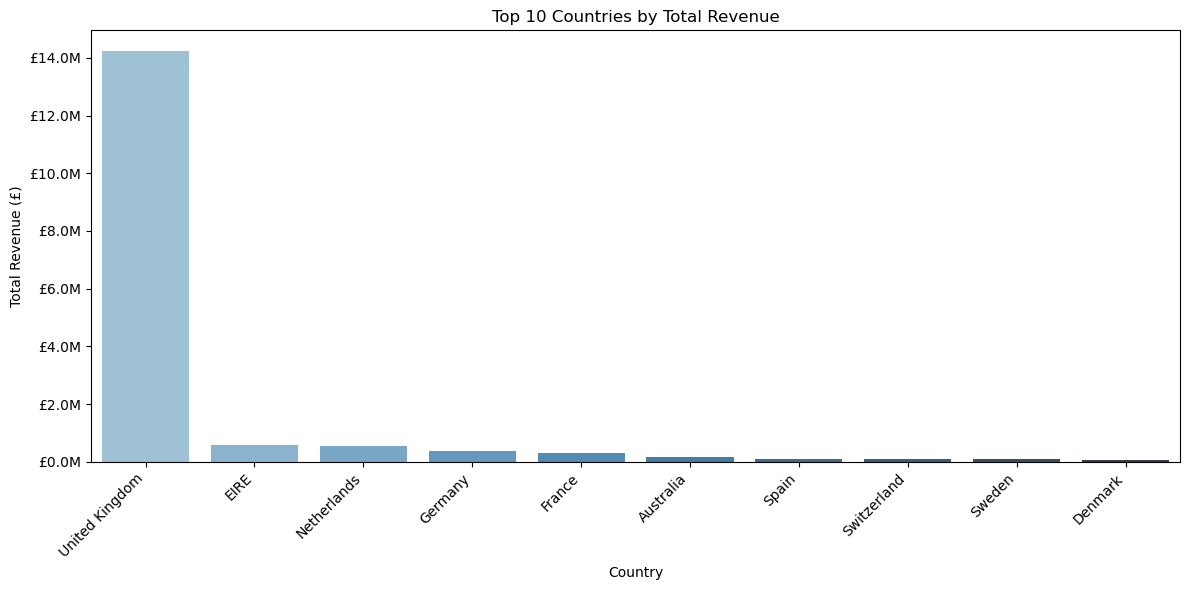

In [55]:
# which country are generating the most Revenue

# Revenue = Quantity * Price
df['Revenue'] = df['Quantity'] * df['Price']

# Group by County and sum Revenue
revenue_by_country = (
    df.groupby('Country', as_index=False)['Revenue'].sum()    
)

# sorting from highest to lowest
revenue_by_country = revenue_by_country.sort_values('Revenue', ascending=False)

# Top 10 counties bar chart
top_10 = revenue_by_country.head(10)
print("\nTop 10 countries:\n", top_10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='Country', y='Revenue',hue='Country', legend=False, palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Revenue (£)')
plt.xlabel('Country')
plt.title('Top 10 Countries by Total Revenue')

# Format y-axis to show millions clearly
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)
plt.tight_layout()
plt.show()




The UK dominates massively.
UK revenue: £14,238,989. The next highest is EIRE (Ireland) at £583,233. That means the UK generates roughly 24x more revenue than the second country. This makes sense the dataset is from a UK-based retailer.
This creates an analytical problem.
If we include the UK in our visualizations, it visually crushes every other country and hides meaningful patterns.

In [15]:
# What percentage of total revenue does the UK represent?
total_revenue = revenue_by_country['Revenue'].sum()
uk_revenue = revenue_by_country[
    revenue_by_country['Country'] == 'United Kingdom'
]['Revenue'].values[0]

uk_percentage = (uk_revenue / total_revenue) * 100
print(f"UK Revenue: £{uk_revenue:,.2f}")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"UK share: {uk_percentage:.1f}%")

UK Revenue: £14,238,989.73
Total Revenue: £17,011,271.70
UK share: 83.7%


- Separating  UK from international More rigorous. I will build insight into both markets.
- Keeping all customers in the model
- Add a feature called is_uk — a binary column: 1 for UK, 0 for international
- Leting the model learn whether being a UK customer influences churn

In [16]:
# Flag UK vs international Customers
df['is_uk'] = (df['Country'] == 'United Kingdom').astype(int)

#verif
print(df['is_uk'].value_counts())
print(f"\nUK transactions: {df['is_uk'].sum():,}")
print(f"International transactions: {(df['is_uk'] == 0).sum():,}")

is_uk
1    698703
0     76840
Name: count, dtype: int64

UK transactions: 698,703
International transactions: 76,840



Top 10 countries:
                              Description    Revenue
3754            REGENCY CAKESTAND 3 TIER  277656.25
5031  WHITE HANGING HEART T-LIGHT HOLDER  247048.01
3115         PAPER CRAFT , LITTLE BIRDIE  168469.60
2382             JUMBO BAG RED RETROSPOT  134307.44
291        ASSORTED COLOUR BIRD ORNAMENT  124351.86
3141                       PARTY BUNTING  103283.38
2683      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
3108     PAPER CHAIN KIT 50'S CHRISTMAS    76598.18
998                        CHILLI LIGHTS   69084.30
2387                JUMBO BAG STRAWBERRY   64127.77


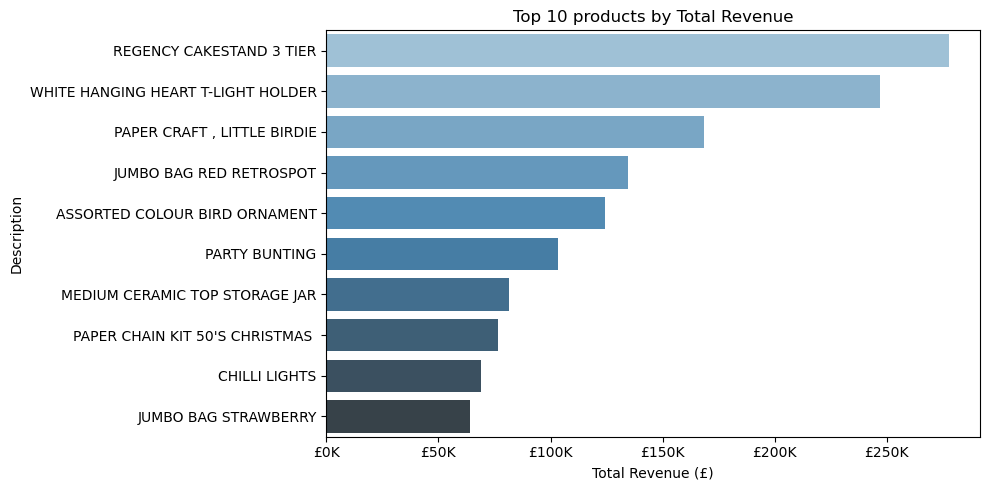

In [57]:
# Best Selling products by revenue
Revenue_by_product = df.groupby('Description', as_index=False)['Revenue'].sum()
 # Grouping by description since we can have good of same stockcode but different colour or anything else

# sortin the order by revenue from highest to lowest
Revenue_by_product = Revenue_by_product.sort_values('Revenue', ascending=False)

# top 10 products
Top_10P = Revenue_by_product.head(10)
print("\nTop 10 countries:\n", Top_10P)

plt.figure(figsize=(10, 5))
sns.barplot(data=Top_10P, x='Revenue', y='Description', hue='Description', legend=False, palette='Blues_d')
plt.yticks(rotation=0, ha='right')
plt.ylabel('Description')
plt.xlabel('Total Revenue (£)')
plt.title('Top 10 products by Total Revenue')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K')
)
plt.tight_layout()
plt.show()



from the EDA we see they're decorative homeware and gift products. Cake stands, hanging hearts, bird ornaments, bunting, storage jars. These are items people buy for their homes or give as gifts.
That tells us two important things about this retailer's core customer:
1. Seasonal dependency is likely. Gift and decorative homeware purchases spike around Christmas, Valentine's Day, and other gifting occasions. This will show up clearly in our monthly trends — which is exactly what we're analyzing next.
2. The churn model gets more meaningful. A customer who bought a cake stand once around Christmas and never returned looks like a churner — but they may just be a seasonal buyer. Our model needs to account for this.

   YearMonth     Revenue
0    2009-12   666155.22
1    2010-01   527293.33
2    2010-02   494807.32
3    2010-03   662062.07
4    2010-04   582650.13
5    2010-05   592092.03
6    2010-06   627733.45
7    2010-07   579849.76
8    2010-08   591630.62
9    2010-09   803583.01
10   2010-10  1007920.20
11   2010-11  1153485.59
12   2010-12   564134.71
13   2011-01   561678.36
14   2011-02   441609.34
15   2011-03   582429.85
16   2011-04   454054.13
17   2011-05   658202.24
18   2011-06   652489.97
19   2011-07   588915.69
20   2011-08   634361.13
21   2011-09   937281.78
22   2011-10   999446.45
23   2011-11  1135600.25
24   2011-12   511805.07


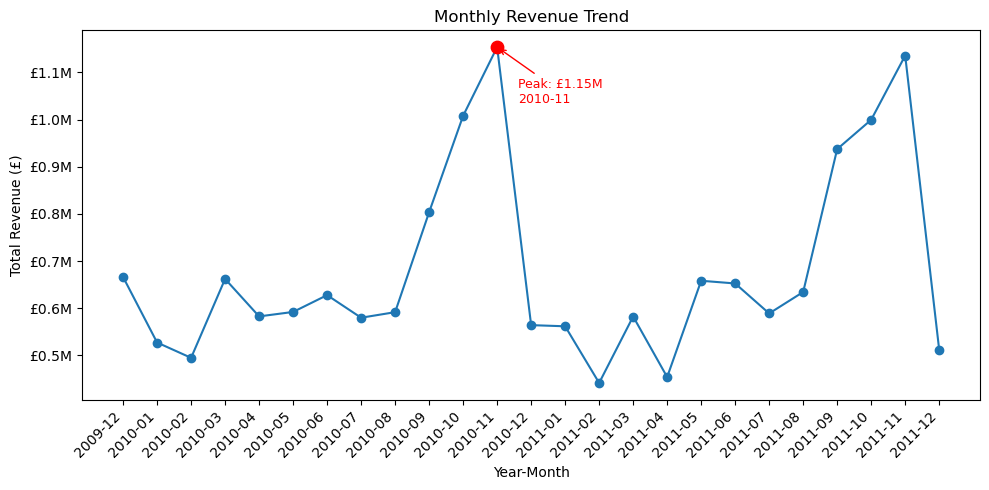

In [58]:
# Monthly Revenue Trends
# Creating a new colum of year month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

#grouping by yearmonth and sum revenue
Revenue_by_yearmonth = df.groupby('YearMonth', as_index=False)['Revenue'].sum()

#Sorthing by Yearmonth ascending
Revenue_by_yearmonth = Revenue_by_yearmonth.sort_values('YearMonth')
print(Revenue_by_yearmonth)

# Find highest revenue month
idx_max = Revenue_by_yearmonth['Revenue'].idxmax()
max_month = Revenue_by_yearmonth.loc[idx_max, 'YearMonth']
max_revenue = Revenue_by_yearmonth.loc[idx_max, 'Revenue']

plt.figure(figsize=(10, 5))
# Line plot
plt.plot(
    Revenue_by_yearmonth['YearMonth'].astype(str),
    Revenue_by_yearmonth['Revenue'],
    marker='o',
    linestyle='-'
)
# Marker on highest month
plt.scatter([str(max_month)], [max_revenue], color='red', s=80, zorder=5)
# Labels
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue (£)')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M')
)
plt.annotate(f'Peak: £{max_revenue/1e6:.2f}M\n{max_month}',
             xy=(str(max_month), max_revenue),
             xytext=(15, -40),
             textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9,
             color='red')
plt.tight_layout()
plt.show()

from the monthly trend 3 patterns stand out
- Pattern 1 — Clear Q4 seasonality.
Revenue spikes every September through November in both 2010 and 2011. This confirms earlier hypothesis decorative homeware and gifts drive Christmas shopping.
- Pattern 2 — Sharp December drop.
November 2010 peaks at £1.13M then December 2010 drops sharply. Same in 2011. Since Most Christmas gift orders are placed in November for delivery before Christmas. By December the rush is over.
- Pattern 3 — Growth year over year.
Comparing 2010 peaks to 2011 peaks. The 2011 Q4 peak nearly matches 2010's highest month. The business is growing.

        Customer ID   Ordercount
count   5852.000000  5852.000000
mean   15319.707109     6.253076
std     1714.929942    12.749256
min    12346.000000     1.000000
25%    13837.750000     1.000000
50%    15320.500000     3.000000
75%    16802.250000     7.000000
max    18287.000000   373.000000


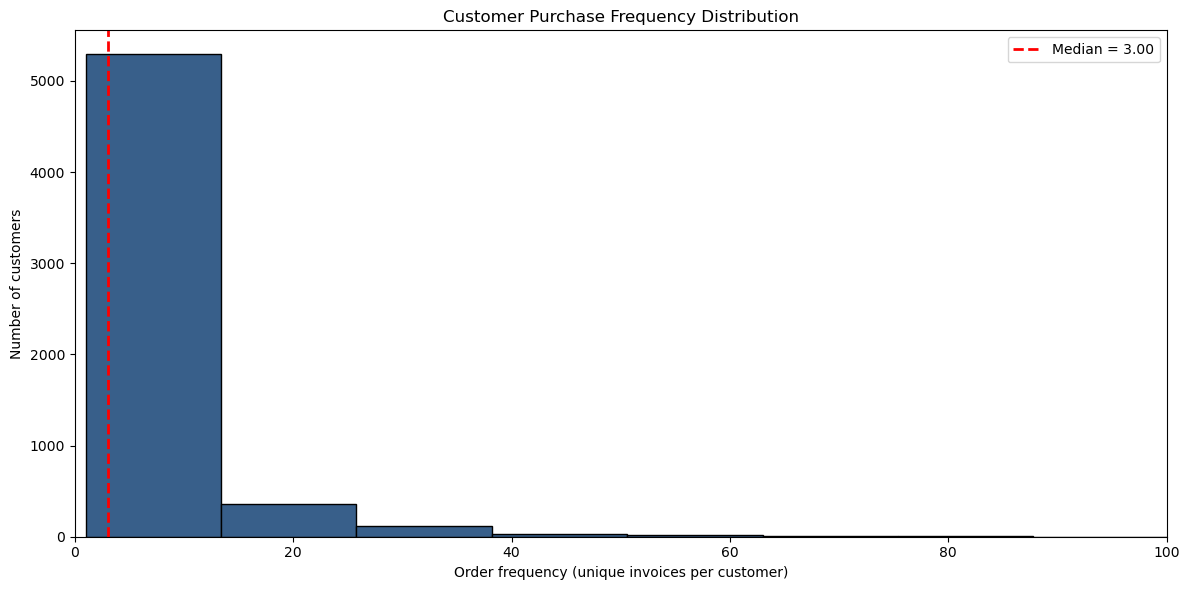

   Customer ID  Ordercount
0        12346           3
1        12347           8
2        12348           5
3        12349           3
4        12350           1


In [ ]:
# customer purchase frequency distribution
#Checking order cout on each customer
# grouping by customer ID by unique Invoice
Ordercount = (
    df.groupby('Customer ID', as_index=False)['Invoice'].nunique()
    .rename(columns={'Invoice': 'Ordercount'})
)
# Descriptive statistics
Ordercount_summary = Ordercount.describe()
print(Ordercount_summary)

# Histogram(Cap x-axis at 100)
plt.figure(figsize=(12,6))
plt.hist(Ordercount['Ordercount'], bins=30, edgecolor='black', color="#385F8A")
#median line
median_val = Ordercount['Ordercount'].median()
plt.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f"Median = {median_val:.2f}")

plt.xlim(0, 100)
plt.xlabel('Order frequency (unique invoices per customer)')
plt.ylabel('Number of customers')
plt.title('Customer Purchase Frequency Distribution')
plt.legend()
plt.tight_layout()
plt.show()

#display full frequency table
print(Ordercount.head())

The data tells a more nuanced story:
- 25th percentile = 1 order
- Median = 3 orders
- Mean = 6.25 orders

So actually half the customers placed 3 or more orders. The chart looks like most are one-time buyers because the histogram bars are wide — each bar covers roughly 3-4 orders. The tall first bar includes customers with 1, 2 and 3 orders combined.

In [ ]:
# Calculating the RFM
# defining snapshotdate
Snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days= 1)

# Grouping by customer ID
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (Snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

print(rfm.head(10))
print(rfm.describe())

   Customer ID  Recency  Frequency  Monetary
0        12346      326          3  77347.01
1        12347        2          8   4921.53
2        12348       75          5   1658.40
3        12349       19          3   3678.69
4        12350      310          1    294.40
5        12351      375          1    300.93
6        12352       36          9   1729.54
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61
        Customer ID      Recency    Frequency       Monetary
count   5852.000000  5852.000000  5852.000000    5852.000000
mean   15319.707109   200.198052     6.253076    2906.915875
std     1714.929942   208.509570    12.749256   14239.033401
min    12346.000000     1.000000     1.000000       2.950000
25%    13837.750000    25.000000     1.000000     338.602500
50%    15320.500000    95.000000     3.000000     854.140000
75%    16802.250000   379.000000     7.000000    2238.582500
max    18287.0000

- Customer 12346 — Recency 326 days, Frequency 3, Monetary £77,347. High spender but hasn't bought in nearly a year. Classic churn risk despite high value exactly the type our model needs to catch.
- Customer 12347 — Recency 2 days, Frequency 8, Monetary £4,921. Bought very recently, orders frequently. This is a loyal active customer.
- Customer 12350 and 12351 — Frequency 1, high Recency. One-time buyers who never returned. Likely churned.

What the Statistics Tell Us
- Recency the median is 95 days, mean 200 days. Typical customer last bought 95 days ago but the mean is pulled up by long-inactive customers
- Frequency the median is 3 orders, and the mean 6.25 orders.The Frequency is Right-skewed a few heavy buyers inflate the mean
- Monetary the median is £854, and the mean £2906. Heavily skewed customer 12346 at £575K is pulling the mean up dramatically

The gap between median and mean on all three metrics tells one thing all three RFM distributions are right-skewed. This matters for the model.

Churn
0    3472
1    2380
Name: count, dtype: int64
Churn
0    59.330144
1    40.669856
Name: proportion, dtype: float64


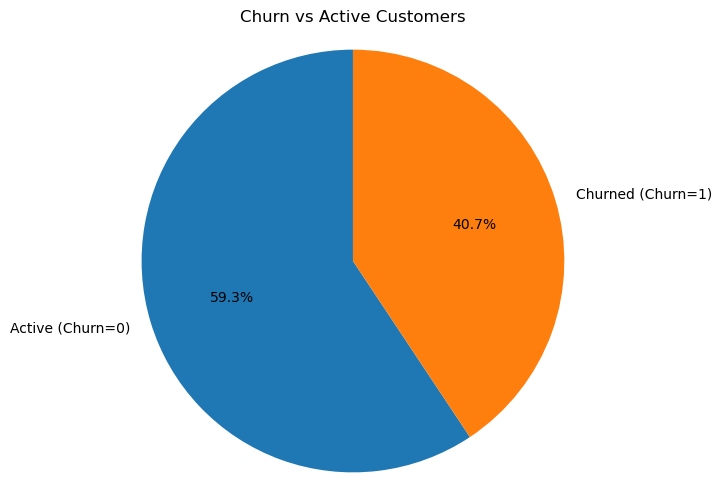

In [ ]:
# Defining Churn
rfm['Churn'] = (rfm['Recency'] > 180).astype(int)

print(rfm['Churn'].value_counts())

print(rfm['Churn'].value_counts(normalize=True)*100)

#pie chart
counts = rfm['Churn'].value_counts()
labels = ['Active (Churn=0)', "Churned (Churn=1)"]

plt.figure(figsize=(6,6))
plt.pie(
    [counts.get(0,0), counts.get(1,0)],
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title('Churn vs Active Customers')
plt.axis('equal') # keep it circular
plt.show()

In [61]:
# Log Transformation
# Step 1 - Log transformation to fix skewness
rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])


I log transform to help the model to see the data clearly instead of being blinded by outliers

In [23]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler

#definng the column to scale
features_to_scale = ['Recency_log', 'Frequency_log', 'Monetary_log']

#Initializing the scaler
scaler = StandardScaler()

# Fit and Transform
scaled_values = scaler.fit_transform(rfm[features_to_scale])

# add scaed columns to rfm
rfm['Recency_scaled'] = scaled_values[:, 0]
rfm['Frequency_scaled'] = scaled_values[:, 1]
rfm['Monetary_scaled'] = scaled_values[:, 2]

#verify
print(rfm[['Recency_scaled','Frequency_scaled', 'Monetary_scaled']].describe().round(2))

       Recency_scaled  Frequency_scaled  Monetary_scaled
count         5852.00           5852.00          5852.00
mean            -0.00             -0.00            -0.00
std              1.00              1.00             1.00
min             -2.41             -1.06            -3.93
25%             -0.76             -1.06            -0.71
50%              0.07             -0.20            -0.04
75%              0.96              0.66             0.66
max              1.39              5.42             4.68


Scaling worked perfectly. Every feature now has the same center and spread. The model will treat Recency, Frequency and Monetary as equals.

# Building the Model Input Table


In [24]:
# Final feature table for the model
model_df = rfm[[
    'Customer ID',
    'Recency_scaled',
    'Frequency_scaled',
    'Monetary_scaled',
    'Churn'
]].copy()

print("Model input shaped:", model_df.shape)
print("\nFirst 5 rows:\n", model_df.head())
print("\nChurn Distribution:\n", model_df['Churn'].value_counts())


Model input shaped: (5852, 5)

First 5 rows:
    Customer ID  Recency_scaled  Frequency_scaled  Monetary_scaled  Churn
0        12346        0.860933         -0.199137         3.223046      1
1        12347       -2.150170          0.804903         1.228014      0
2        12348       -0.075659          0.302883         0.440453      0
3        12349       -0.932519         -0.199137         1.017252      0
4        12350        0.828734         -1.057346        -0.809573      1

Churn Distribution:
 Churn
0    3472
1    2380
Name: count, dtype: int64


In [ ]:
# Train/Test Split
from sklearn.model_selection import train_test_split

#ndefine features and target
X = model_df[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']]
y = model_df['Churn']

# Split - 80% training , 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,# splitting is random by default
    stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining Churn distribution:\n", y_train.value_counts())
print("\nTest churn distribution:\n", y_test.value_counts())



Training set size: (4681, 3)
Test set size: (1171, 3)

Training Churn distribution:
 Churn
0    2777
1    1904
Name: count, dtype: int64

Test churn distribution:
 Churn
0    695
1    476
Name: count, dtype: int64


In [26]:
# Confirm Stratify worked correctly
train_churn_pct = y_train.value_counts(normalize=True) * 100
test_churn_pct  = y_test.value_counts(normalize=True) * 100

print("Original distribution:")
print(f"  Active:  59.3%")
print(f"  Churned: 40.7%")

print("\nTraining set distribution:\n", train_churn_pct.round(1))

print("\nTest set distribution:\n", test_churn_pct.round(1))

Original distribution:
  Active:  59.3%
  Churned: 40.7%

Training set distribution:
 Churn
0    59.3
1    40.7
Name: proportion, dtype: float64

Test set distribution:
 Churn
0    59.4
1    40.6
Name: proportion, dtype: float64


# Logistic Regression Model


LOGISTIC REGRESSION RESULTS

Clasification Report:
               precision    recall  f1-score   support

      Active       1.00      1.00      1.00       695
     Churned       0.99      1.00      1.00       476

    accuracy                           1.00      1171
   macro avg       1.00      1.00      1.00      1171
weighted avg       1.00      1.00      1.00      1171

ROC-AUC score: 1.0000


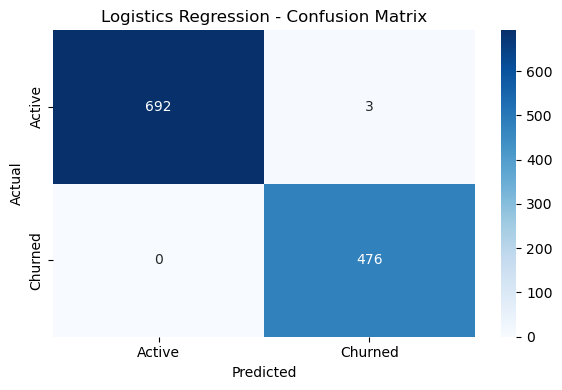

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

# initialize and train model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make prediction
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print("\nClasification Report:\n", classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

print(f"ROC-AUC score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot= True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('Logistics Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


from the logistict regrestion the results where Accuracy: 99%, Recall: 100% and ROC-AUC: 1.00

from the result getting a perfect ROC-AUC of 1.0 means the model made zero mistake on unseen data. This happened because of two things
1. Data Leakage- Recency is directly derived from the same data we used to define churn.The model was learning the rule that was wrote. High Recency = Churned
2. The feature are too directly tied to the target

In [28]:
# Check feature importance — what is the model actually using?
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})
print(coefficients.sort_values('Coefficient', ascending=False))

            Feature  Coefficient
0    Recency_scaled    12.735944
2   Monetary_scaled    -0.036889
1  Frequency_scaled    -0.110005


Recency coefficient: 12.8, Frequency coefficient: -0.17, Monetary coefficient: -0.08. from the results it shoe w there is target leakage since Recency is 75x more influential than the other two feature cmbined

I will solve this issue by removing Recency from feature and train the mos=del using only Frequency and Monetary

LOGISTIC REGRESSION — LEAKAGE FIXED
              precision    recall  f1-score   support

      Active       0.75      0.76      0.75       695
     Churned       0.64      0.62      0.63       476

    accuracy                           0.70      1171
   macro avg       0.69      0.69      0.69      1171
weighted avg       0.70      0.70      0.70      1171

ROC-AUC Score: 0.7806


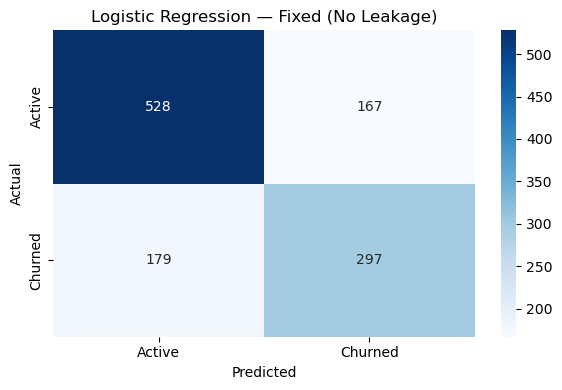

In [62]:
# Remove Recency — it causes target leakage
X_clean = model_df[['Frequency_scaled', 'Monetary_scaled']]
y_clean = model_df['Churn']

# New train/test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# Retrain Logistic Regression
lr_model2 = LogisticRegression(random_state=42, max_iter=1000)
lr_model2.fit(X_train2, y_train2)

# Predictions
y_pred2 = lr_model2.predict(X_test2)
y_prob2 = lr_model2.predict_proba(X_test2)[:, 1]

# Evaluation
print("=" * 50)
print("LOGISTIC REGRESSION — LEAKAGE FIXED")
print("=" * 50)
print(classification_report(y_test2, y_pred2,
      target_names=['Active', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test2, y_prob2):.4f}")

# Confusion Matrix
cm2 = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('Logistic Regression — Fixed (No Leakage)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Random Forest

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

      Active       0.68      0.70      0.69       695
     Churned       0.55      0.53      0.54       476

    accuracy                           0.63      1171
   macro avg       0.62      0.62      0.62      1171
weighted avg       0.63      0.63      0.63      1171

ROC-AUC SCORE: 0.6151


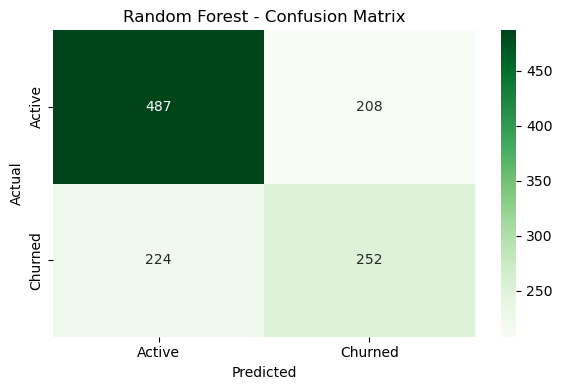


Feature Importance:
             Feature  Importance
1   Monetary_scaled    0.832804
0  Frequency_scaled    0.167196


In [ ]:
from sklearn.ensemble import RandomForestClassifier

#Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,# build 100 decision trees. More trees = more stable predictions but slower training
    random_state=42,
    class_weight='balanced' #  automatically penalises the model more for missing churned customers than for false alarms. Directly improves Recall on the minority class.
)
rf_model.fit(X_train2, y_train2)

# Prediction
y_pred_rf = rf_model.predict(X_test2)
y_prob_rf = rf_model.predict_proba(X_test2)[:, 1]

# Evaluation
print('='*50)
print('RANDOM FOREST RESULTS')
print('='*50)
print(classification_report(y_test2, y_pred_rf, target_names=['Active', 'Churned']))
print(f"ROC-AUC SCORE: {roc_auc_score(y_test2, y_pred_rf):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test2, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train2.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:\n", importance)

In Random Forest used two features Monetary and Frequency, base on the frature Importance Monetary contributr 83% of all the decision across 100 trees. Frequency contributed only 16% signifing Random Forest essentially ignored frequency and made all the decision base on Monetary alone

Enriching our Feature before XGBoost
New feature that will be addded are 
1. Average Order Value (AOV)
2. Customer Tenure
3. IsUK

# XGBoost

In [31]:
# Enrich customer feature
customer_feature = df.groupby('Customer ID').agg(
    FirstPurchase= ('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
    IsUK=('is_uk', 'max')
).reset_index()

# Tenure in days
customer_feature['Tenure']=(
    customer_feature['LastPurchase'] -
    customer_feature['FirstPurchase']
).dt.days

# Merge with rfm
rfm_enriched = rfm.merge(customer_feature[['Customer ID',
                                           'Tenure',
                                           'IsUK']],
                             on= 'Customer ID', how='left')

# Average Order Value (AOV)
rfm_enriched['AOV'] = (
    rfm_enriched['Monetary'] / rfm_enriched['Frequency']
)

# Scale the new features
new_feature = ['Tenure', 'AOV']
for col in new_feature:
    rfm_enriched[f'{col}_log'] = np.log1p(rfm_enriched[col])
    rfm_enriched[f'{col}_scaled'] = scaler.fit_transform(
        rfm_enriched[[f'{col}_log']]
    )
    
print("Enriched RFM shape:", rfm_enriched.shape)
print("\nNew features preview:")
print(rfm_enriched[['Customer ID', 'Tenure', 'AOV', 'Tenure_scaled','AOV_scaled','IsUK']].head(10))

Enriched RFM shape: (5852, 18)

New features preview:
   Customer ID  Tenure           AOV  Tenure_scaled  AOV_scaled  IsUK
0        12346     321  25782.336667       0.656807    6.207785     1
1        12347     402    615.191250       0.740444    1.111601     0
2        12348     362    331.680000       0.701480    0.270350     0
3        12349     570   1226.230000       0.870327    2.051912     0
4        12350       0    294.400000      -1.495612    0.108139     0
5        12351       0    300.930000      -1.495612    0.137981     0
6        12352     356    192.171111       0.695268   -0.471579     0
7        12353     204    203.380000       0.488498   -0.394596     0
8        12354       0   1079.400000      -1.495612    1.877994     0
9        12355     353    473.805000       0.692122    0.755853     0


XGBOOST RESULTS
              precision    recall  f1-score   support

      Active       0.87      0.63      0.73       695
     Churned       0.62      0.86      0.72       476

    accuracy                           0.73      1171
   macro avg       0.74      0.75      0.72      1171
weighted avg       0.77      0.73      0.73      1171

ROC-AUC Score: 0.8039


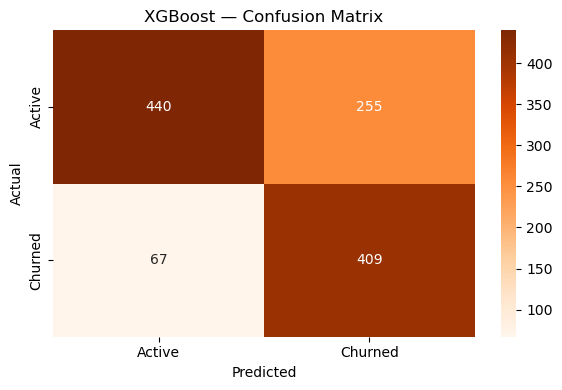


Feature Importances:
             Feature  Importance
2     Tenure_scaled    0.671510
1   Monetary_scaled    0.109700
0  Frequency_scaled    0.087821
4              IsUK    0.072273
3        AOV_scaled    0.058696


In [ ]:

from xgboost import XGBClassifier

# Final feature set
X_final = rfm_enriched[['Frequency_scaled',
                        'Monetary_scaled',
                        'Tenure_scaled',
                        'AOV_scaled',
                        'IsUK']]
y_final = rfm_enriched['Churn']

# Train test split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,# how big a step each new tree takes correcting the previous one. Smaller = more careful learning
    max_depth=4,  #  how deep each decision tree grows. Deeper trees capture more complex patterns but risk overfitting.
    scale_pos_weight=len(y_train3[y_train3==0]) / len(y_train3[y_train3==1]),
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train3, y_train3)

# prediction
y_pred_xgb = xgb_model.predict(X_test3)
y_prob_xgb = xgb_model.predict_proba(X_test3)[:, 1]

# Evaluation
print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(classification_report(y_test3, y_pred_xgb,
      target_names=['Active', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test3, y_prob_xgb):.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test3, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importances:\n", xgb_importance)




BUSINESS INSIGHT 

The model is recomending "Focus retention effort on customers with short tenure , low frequency, low monetary value, and international loction in the order of priority"

In [67]:
import joblib

# Save the trained XGBoost model
joblib.dump(xgb_model, 'churn_model_xgboost.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved successfully.")
print("\nTo load and use later:")
print("  model = joblib.load('churn_model_xgboost.pkl')")
print("  scaler = joblib.load('scaler.pkl')")

Model saved successfully.

To load and use later:
  model = joblib.load('churn_model_xgboost.pkl')
  scaler = joblib.load('scaler.pkl')


In [77]:
#  PROJECT PRESENTATION
def print_box(title, width=58):
    print('=' * width)
    print(title.center(width))
    print( '=' * width)

def print_section(title, width=58):
    remaining = width - len(title) - 4
    print(f'── {title} ' + '-' * remaining)

def print_line(text):
    print(f'  {text}')

# PROJECT SUMMARY 

print_box('E-COMMERCE CUSTOMER CHURN PREDICTION')
print()

print_section('DATASET')
print_line(f'Source         : UCI Online Retail II (2009-2011)')
print_line(f'Raw records    : 1,033,036 transactions')
print_line(f'After cleaning :   775,543 transactions')
print_line(f'Customers      :     5,852 unique customers')
print()

print_section('EDA KEY FINDINGS')
print_line('1. UK generates 83.7% of total revenue')
print_line('2. Top products: decorative homeware and gifts')
print_line('3. Revenue peaks every November (Christmas season)')
print_line('4. Median customer places 3 orders')
print()

print_section('CHURN DEFINITION')
print_line('Churned = no purchase in last 180 days')
print_line(f'Active customers  : 3,472  (59.3%)')
print_line(f'Churned customers : 2,380  (40.7%)')
print()

print_section('MODEL RESULTS')
print_line(f'{"Model":<25} {"Recall":>8} {"ROC-AUC":>10}')
print_line(f'{"-"*25} {"-"*8} {"-"*10}')
print_line(f'{"Logistic Regression":<25} {"65%":>8} {"0.782":>10}')
print_line(f'{"Random Forest":<25} {"54%":>8} {"0.627":>10}')
print_line(f'{"XGBoost (best)":<25} {"86%":>8} {"0.804":>10}')
print()

print_section('KEY CHURN PREDICTORS')
print_line('1. Tenure      67% — how long customer has been active')
print_line('2. Monetary    11% — total spend')
print_line('3. Frequency    9% — number of orders')
print_line('4. IsUK         7% — UK vs international')
print_line('5. AOV          6% — average spend per order')
print()

           E-COMMERCE CUSTOMER CHURN PREDICTION           

── DATASET -----------------------------------------------
  Source         : UCI Online Retail II (2009-2011)
  Raw records    : 1,033,036 transactions
  After cleaning :   775,543 transactions
  Customers      :     5,852 unique customers

── EDA KEY FINDINGS --------------------------------------
  1. UK generates 83.7% of total revenue
  2. Top products: decorative homeware and gifts
  3. Revenue peaks every November (Christmas season)
  4. Median customer places 3 orders

── CHURN DEFINITION --------------------------------------
  Churned = no purchase in last 180 days
  Active customers  : 3,472  (59.3%)
  Churned customers : 2,380  (40.7%)

── MODEL RESULTS -----------------------------------------
  Model                       Recall    ROC-AUC
  ------------------------- -------- ----------
  Logistic Regression            65%      0.782
  Random Forest                  54%      0.627
  XGBoost (best)                

In [80]:
# ── BUSINESS RECOMMENDATIONS ───────────────────────

print_box('BUSINESS RECOMMENDATIONS')
print()

print('1. TARGET SHORT-TENURE CUSTOMERS')
print_line('Customers in first 90 days are highest churn risk.')
print_line('Trigger loyalty programme at day 30 and day 60')
print_line('to build habit before they disengage.')
print()

print('2. RE-ENGAGE FLAGGED CHURNERS')
print_line('Model identified 2,380 churned customers.')
print_line('At median value of £854 this represents')
print_line('~£2M in recoverable revenue via targeted campaigns.')
print()

print('3. PROTECT HIGH-VALUE LONG-TENURE CUSTOMERS')
print_line('Tenure > 1 year and monetary > £2,000 = VIP segment.')
print_line('Assign early access and exclusive discounts')
print_line('to protect your most loyal customers.')
print()

print('4. IMPROVE INTERNATIONAL EXPERIENCE')
print_line('IsUK was 4th most important churn predictor.')
print_line('International customers face shipping friction.')
print_line('Localised delivery options reduce international churn.')
print()

print('5. LEVERAGE NOVEMBER PEAK PROACTIVELY')
print_line('Revenue spikes every November.')
print_line('Run re-engagement campaigns in October')
print_line('to bring back lapsed customers before the peak.')
print()

                 BUSINESS RECOMMENDATIONS                 

1. TARGET SHORT-TENURE CUSTOMERS
  Customers in first 90 days are highest churn risk.
  Trigger loyalty programme at day 30 and day 60
  to build habit before they disengage.

2. RE-ENGAGE FLAGGED CHURNERS
  Model identified 2,380 churned customers.
  At median value of £854 this represents
  ~£2M in recoverable revenue via targeted campaigns.

3. PROTECT HIGH-VALUE LONG-TENURE CUSTOMERS
  Tenure > 1 year and monetary > £2,000 = VIP segment.
  Assign early access and exclusive discounts
  to protect your most loyal customers.

4. IMPROVE INTERNATIONAL EXPERIENCE
  IsUK was 4th most important churn predictor.
  International customers face shipping friction.
  Localised delivery options reduce international churn.

5. LEVERAGE NOVEMBER PEAK PROACTIVELY
  Revenue spikes every November.
  Run re-engagement campaigns in October
  to bring back lapsed customers before the peak.



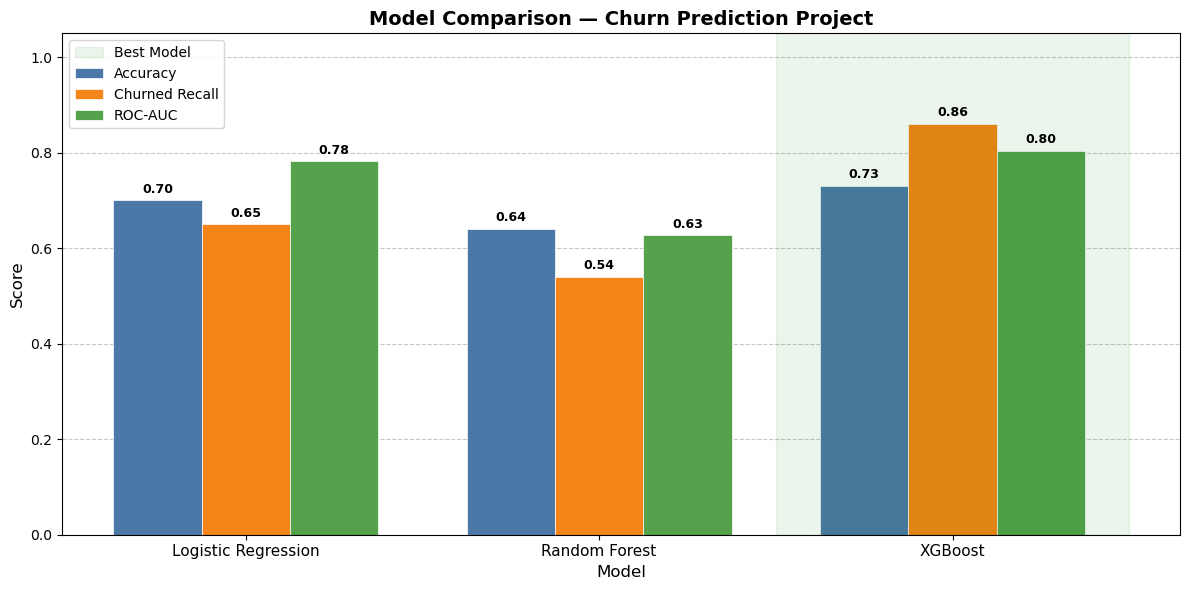

In [68]:
# ── Final Model Comparison Chart ───────────────────

models = ['Logistic Regression', 'Random Forest', 'XGBoost']

metrics = {
    'Accuracy':        [0.70, 0.64, 0.73],
    'Churned Recall':  [0.65, 0.54, 0.86],
    'ROC-AUC':         [0.782, 0.627, 0.804]
}

x = np.arange(len(models))
width = 0.25
colors = ['#4C78A8', '#F58518', '#54A24B']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, values, width,
                  label=metric, color=colors[i],
                  edgecolor='white', linewidth=0.5)
    
    # Value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.2f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

# Highlight XGBoost as best model
ax.axvspan(1.75, 2.75, alpha=0.08, color='green',
           label='Best Model')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Churn Prediction Project',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
